In [5]:
# Examine the dataset 

import pandas as pd 
df = pd.read_csv(r'C:\Users\dmiracju\Desktop\Fraud_DS_Project\Data\fraud_risk_dataset.csv')
# View data(
df.head()

,transaction_id,customer_age,account_tenure_months,region,transaction_amount,merchant_category,payment_method,device_type,num_transactions_24h,international,previous_chargebacks,fraud
0,100000,65,68,South,130.13,Travel,Digital Wallet,Tablet,4,0,0,0
1,100001,22,4,South,28.27,Travel,Debit,Tablet,1,0,0,0
2,100002,43,53,South,304.83,Travel,Credit,Tablet,2,0,0,0
3,100003,72,69,West,39.87,Restaurants,Debit,Tablet,1,0,1,1
4,100004,21,8,South,125.73,Gas,Debit,Desktop,3,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         5000 non-null   int64  
 1   customer_age           5000 non-null   int64  
 2   account_tenure_months  5000 non-null   int64  
 3   region                 5000 non-null   object 
 4   transaction_amount     5000 non-null   float64
 5   merchant_category      5000 non-null   object 
 6   payment_method         5000 non-null   object 
 7   device_type            5000 non-null   object 
 8   num_transactions_24h   5000 non-null   int64  
 9   international          5000 non-null   int64  
 10  previous_chargebacks   5000 non-null   int64  
 11  fraud                  5000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 468.9+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,5000.0,102499.50000,1443.520003,100000.00,101249.7500,102499.500,103749.25,104999.00
customer_age,5000.0,45.70120,16.575430,18.00,31.0000,45.000,60.00,74.00
account_tenure_months,5000.0,88.85400,52.354458,1.00,43.0000,88.000,134.00,179.00
transaction_amount,5000.0,119.42684,120.207801,0.01,33.5425,83.545,167.12,1167.35
num_transactions_24h,5000.0,2.00760,1.419276,0.00,1.0000,2.000,3.00,10.00
international,5000.0,0.15040,0.357499,0.00,0.0000,0.000,0.00,1.00
previous_chargebacks,5000.0,0.30160,0.558122,0.00,0.0000,0.000,1.00,5.00
fraud,5000.0,0.07260,0.259505,0.00,0.0000,0.000,0.00,1.00


In [8]:
df.value_counts()

transaction_id  customer_age  account_tenure_months  region     transaction_amount  merchant_category  payment_method  device_type  num_transactions_24h  international  previous_chargebacks  fraud
100000          65            68                     South      130.13              Travel             Digital Wallet  Tablet       4                     0              0                     0        1
100001          22            4                      South      28.27               Travel             Debit           Tablet       1                     0              0                     0        1
100002          43            53                     South      304.83              Travel             Credit          Tablet       2                     0              0                     0        1
100003          72            69                     West       39.87               Restaurants        Debit           Tablet       1                     0              1                     1     

In [9]:
df['fraud'].value_counts(normalize=True)

fraud
0    0.9274
1    0.0726
Name: proportion, dtype: float64

In [10]:
# Fraud cases are rare, this means that the target variable has an imbalance

In [11]:
# Group analysis 
region_fraud = df.groupby('region')['fraud'].mean().sort_values(ascending = False)
print('Average amount of fraud by region', region_fraud)

Average amount of fraud by region region
Midwest      0.083957
South        0.078208
Northeast    0.065182
West         0.063091
Name: fraud, dtype: float64


In [12]:
#Group analysis 
pay_method_fraud = df.groupby('payment_method')['fraud'].mean().sort_values(ascending=False)
print('Fraud by payment method', pay_method_fraud)

Fraud by payment method payment_method
Digital Wallet    0.076923
Credit            0.072171
Debit             0.068657
Name: fraud, dtype: float64


In [13]:
#Group analysis 
merchant_fraud = df.groupby('merchant_category')['fraud'].mean().sort_values(ascending = False)
print('Fraud by Mechant', merchant_fraud)


Fraud by Mechant merchant_category
Luxury             0.088191
Travel             0.079932
Clothing           0.073836
Restaurants        0.073290
Groceries          0.072700
Gas                0.070866
Online Services    0.067633
Electronics        0.052083
Name: fraud, dtype: float64


In [14]:
#Group analysis 
dev_type_fraud = df.groupby('device_type')['fraud'].mean().sort_values(ascending = False)
print('fraud by device type', dev_type_fraud)

fraud by device type device_type
Mobile     0.076145
Tablet     0.072253
Desktop    0.069378
Name: fraud, dtype: float64


In [15]:
# Visual exploration 
import matplotlib as plt 
import seaborn as sns 

<Axes: title={'center': 'Fraud'}, xlabel='fraud'>

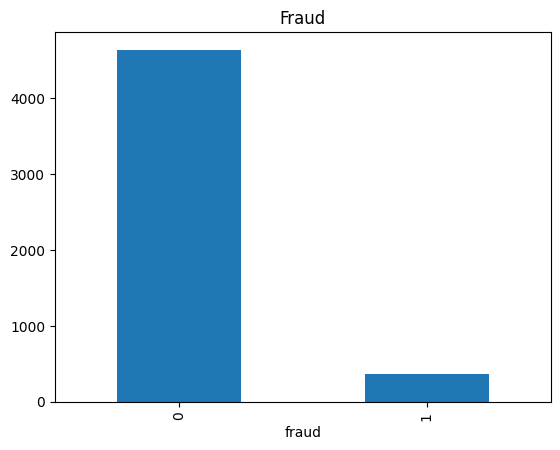

In [16]:
# Fraud target balance 
df['fraud'].value_counts().plot(kind = 'bar', title = 'Fraud')

<Axes: >

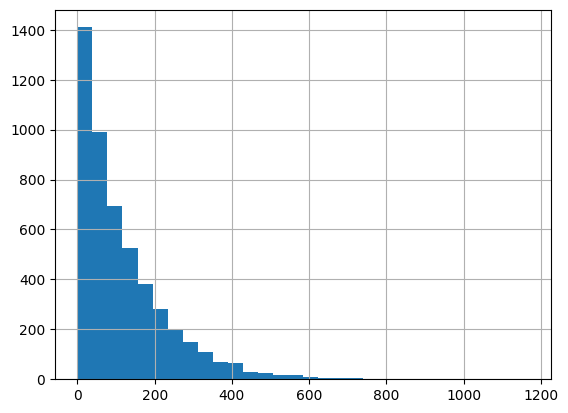

In [17]:
# Transactin amount distribution 
df['transaction_amount'].hist(bins=30)


<Axes: xlabel='fraud', ylabel='transaction_amount'>

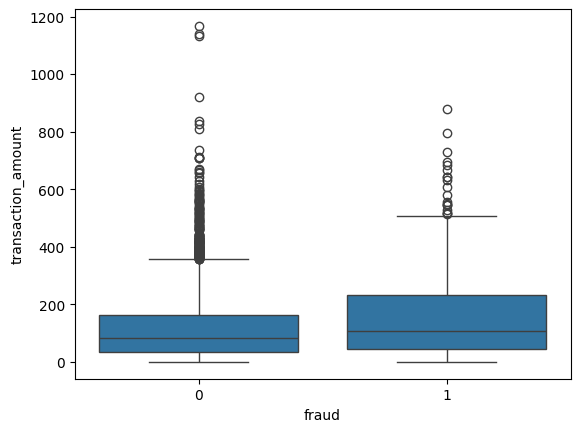

In [18]:
# Fraud vs Amount 

sns.boxplot(x = 'fraud', y = 'transaction_amount', data = df)

<Axes: ylabel='merchant_category'>

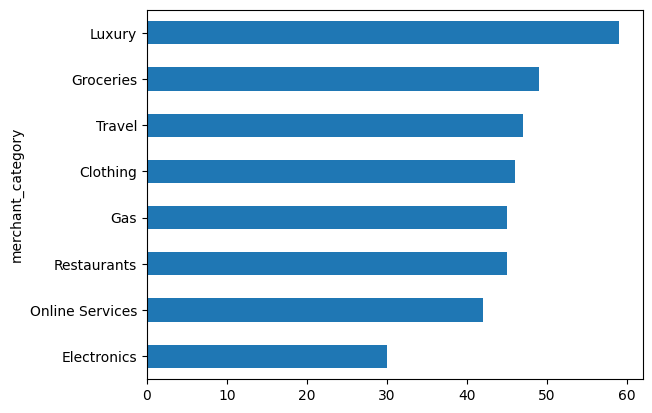

In [19]:
# Fraud by category 

df.groupby('merchant_category')['fraud'].sum().sort_values().plot(kind = 'barh')

<Axes: title={'center': 'Fraud by Region'}, xlabel='region'>

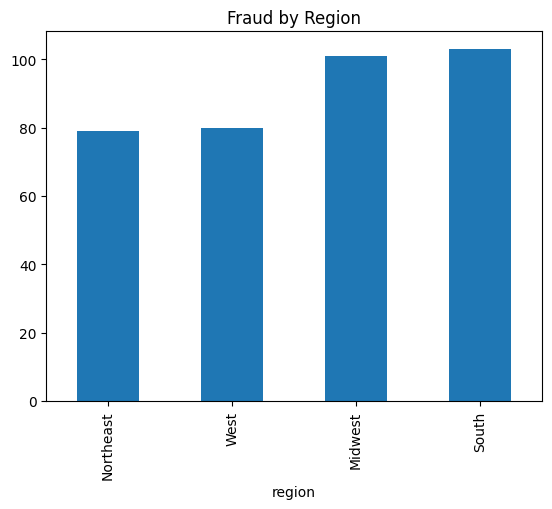

In [20]:
# Fraud by region 

df.groupby('region')['fraud'].sum().sort_values().plot(kind = 'bar', title = 'Fraud by Region')

<Axes: title={'center': 'Fraudulent Payment Methods'}, ylabel='fraud'>

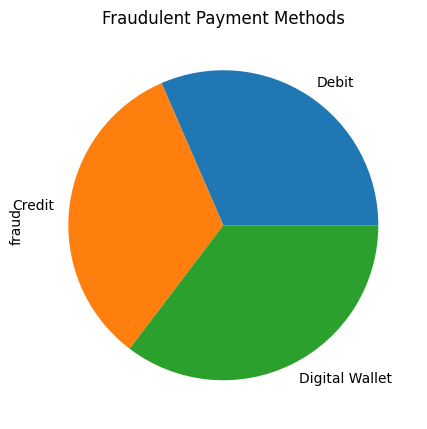

In [21]:
# Fraud by payment methods

df.groupby('payment_method')['fraud'].mean().sort_values().plot(kind = 'pie', title = 'Fraudulent Payment Methods', figsize=[5,6])

<Axes: xlabel='device_type'>

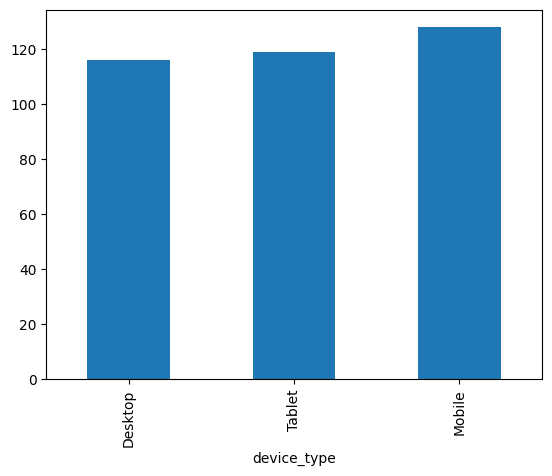

In [22]:
# Fraud by device type
df.groupby('device_type')['fraud'].sum().sort_values().plot(kind = 'bar')

In [23]:
numeric_df = df.select_dtypes(include = ['number']) # Extract numeric values only from dataset 

<Axes: >

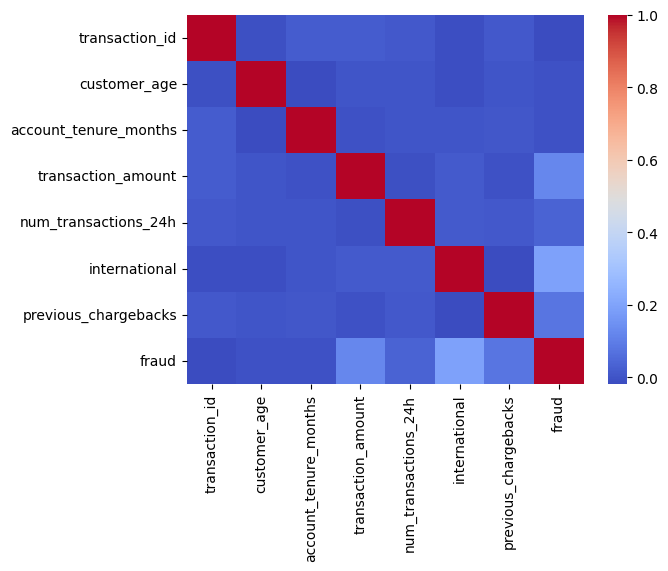

In [24]:
# Correlation Matrix Heatmap 
sns.heatmap(numeric_df.corr(), annot = False, cmap = 'coolwarm')

<Axes: xlabel='fraud'>

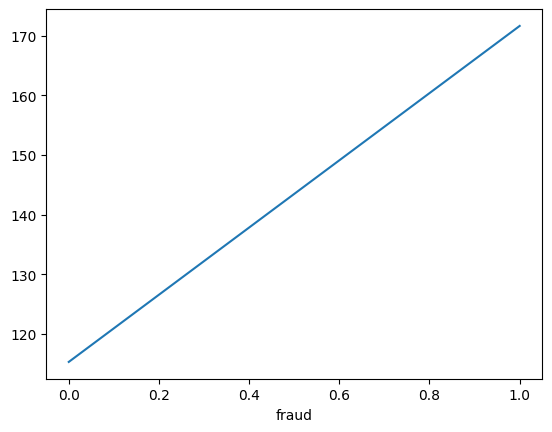

In [25]:
df.groupby('fraud')['transaction_amount'].mean().sort_values().plot(kind = 'line')

<Axes: ylabel='fraud'>

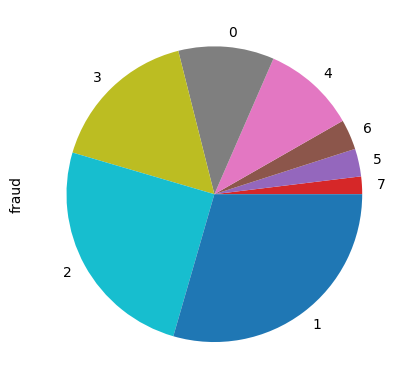

In [26]:
df.groupby('num_transactions_24h')['fraud'].sum().sort_values().plot(kind = 'pie')

In [29]:
# Which category appear more risky ? Luxury, groccery, and travel have the most amount of recored fraud. 
# Do large amounts of increase fraud ? An uptrend in fraudaulent transaction as the amount begins to increase. 
# Which payment methods looks safest ? Debit
# Are international transactions riskier ? yes
# Are velocity spikes suspicous ? There is a high amount of fraud from between the 1 - 3 transactions amounts in the 24hr window

# Note: Fraudster steal high valuble goods using fast, less traceable channels like wallets  

In [ ]:
df

,transaction_id,customer_age,account_tenure_months,region,transaction_amount,merchant_category,payment_method,device_type,num_transactions_24h,international,previous_chargebacks,fraud
0,100000,65,68,South,130.13,Travel,Digital Wallet,Tablet,4,0,0,0
1,100001,22,4,South,28.27,Travel,Debit,Tablet,1,0,0,0
2,100002,43,53,South,304.83,Travel,Credit,Tablet,2,0,0,0
3,100003,72,69,West,39.87,Restaurants,Debit,Tablet,1,0,1,1
4,100004,21,8,South,125.73,Gas,Debit,Desktop,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104995,49,69,Northeast,88.01,Online Services,Digital Wallet,Tablet,0,0,1,0
4996,104996,27,136,Midwest,25.96,Restaurants,Credit,Mobile,1,0,1,0
4997,104997,19,77,Northeast,197.17,Restaurants,Debit,Mobile,2,0,1,0
4998,104998,49,62,Northeast,88.32,Gas,Debit,Desktop,1,0,0,0


In [ ]:
df['fraud'].mean()

np.float64(0.0726)